In [4]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import numpy as onp
from ase.atoms import Atoms
from ase.visualize import view

import jax.numpy as jnp

from msmjax.benchmark_tools import path_input_structures
from msmjax.core.shortrange import compute_distance_vectors

# Get structure(s)

In [5]:
structures = onp.load(path_input_structures / "structures_500.npz")

In [8]:
PBC = (True, True, True)

idx = 1
# n_atoms = 5

pos = structures["positions"][idx].astype(onp.float64)
chg = structures["charges"][idx].astype(onp.float64)
cell = structures["cells"][idx].astype(onp.float64)

atoms = Atoms(positions=pos, cell=cell, pbc=PBC)
view(atoms)

In [10]:
# side_length = cell[0, 0]
# atoms_tilted = atoms.copy()
# atoms_tilted.set_cell(
#     onp.concatenate([onp.array([0.8, 1.0, 1.3]) * side_length, [70, 85, 108]]),
#     scale_atoms=True)
# 
# view(atoms_tilted)
# 
# pos_tilted = atoms_tilted.get_positions()
# cell_tilted = atoms_tilted.get_cell()[...]

In [48]:
def get_all_distances_custom(pos, cell):
    mg = onp.meshgrid(onp.arange(pos.shape[0]), onp.arange(pos.shape[0]), indexing='ij')
    inds_all_pairs = tuple(i.ravel() for i in mg)
    deltas = compute_distance_vectors(
        positions=pos,
        cell=cell,
        pair_indices=inds_all_pairs,
        pbc=jnp.array(PBC),
    )
    distances = onp.linalg.norm(deltas, axis=1)
    distances = distances.reshape((pos.shape[0], pos.shape[0]))
    return distances

In [43]:
def make_tilted_atoms(atoms, lattice_vec_scale_factors, new_angles):
    new_lengths = atoms.cell.cellpar()[:3] * lattice_vec_scale_factors
    new_angles = onp.asarray(new_angles)
    atoms_tilted = atoms.copy()
    atoms_tilted.set_cell(
        onp.concatenate([new_lengths, new_angles]), scale_atoms=True
    )
    return atoms_tilted

In [44]:
view(make_tilted_atoms(atoms, [0.85, 1.05, 1.3], [70, 98, 121]))

In [15]:
def get_max_cutoff_3d(cell: jnp.ndarray):
    """Get the maximum cutoff value that fits into a 3D cell.

    Args:
        cell: Cell, shape=(3, 3).

    Returns:
        Cutoff radius
    """
    return jnp.min(
        jnp.fabs(
            jnp.linalg.det(cell)
            / jnp.array(
                [
                    jnp.linalg.norm(jnp.cross(i, j))
                    for i, j in zip(cell, jnp.roll(cell, 1, axis=0))
                ]
            )
        )
        / 2.0
    )

# Calculate distances

In [66]:
LATTICE_VEC_SCALE_FACTORS = [0.85, 1.05, 1.3]
NEW_ANGLES = [70, 98, 121]
# LATTICE_VEC_SCALE_FACTORS = [0.8, 1.0, 1.3]
# NEW_ANGLES = [70, 85, 108]

for idx in range(structures["positions"].shape[0]):
    atoms = Atoms(
        positions=structures["positions"][idx].astype(onp.float64),
        cell=structures["cells"][idx].astype(onp.float64), 
        pbc=PBC,
    )
    atoms_tilted = make_tilted_atoms(atoms, LATTICE_VEC_SCALE_FACTORS, NEW_ANGLES)
    pos_tilted = atoms_tilted.get_positions()
    cell_tilted = atoms_tilted.get_cell()[...]
    
    max_cutoff = get_max_cutoff_3d(cell_tilted)
    
    distances_custom = get_all_distances_custom(pos_tilted, cell_tilted)
    distances_ase = atoms_tilted.get_all_distances(mic=True)
    
    dists_custom_within_cutoff = distances_custom[distances_custom < max_cutoff]
    dists_ase_within_cutoff = distances_ase[distances_ase < max_cutoff]
    assert onp.allclose(
        dists_custom_within_cutoff,
        dists_ase_within_cutoff,
    )

## Custom

## ase

In [14]:
deltas_ase = atoms_tilted.get_all_distances(mic=True)

## Compare

In [38]:
max_cutoff = get_max_cutoff_3d(cell_tilted)

In [35]:
deltas.shape, deltas_ase.shape

((500, 500), (500, 500))

In [36]:
onp.allclose(deltas, deltas_ase)

False

In [37]:
onp.allclose(deltas[deltas < max_cutoff], deltas_ase[deltas_ase < max_cutoff])

True

## From Nico

In [11]:
def get_distances(coordinates, cell_size):
    "Return square of all distances"
    delta = coordinates - coordinates[:, jnp.newaxis, :]
    if cell_size is not None:
        delta -= jnp.einsum(
            "ijk,kl",
            jnp.round(jnp.einsum("ijk,kl", delta, jnp.linalg.inv(cell_size))),
            cell_size,
        )
        radius2 = jnp.sum(delta**2, axis=-1)
        return radius2

In [14]:
deltas_nu = onp.sqrt(get_distances(coordinates=pos_tilted, cell_size=cell_tilted))

In [15]:
deltas

array([[0.       , 4.48834  , 1.5335939, 6.6913943, 4.530539 ],
       [4.48834  , 0.       , 5.8361716, 3.8162394, 3.4297755],
       [1.5335939, 5.8361716, 0.       , 3.7640655, 5.088947 ],
       [6.6913943, 3.8162394, 3.7640655, 0.       , 5.850705 ],
       [4.530539 , 3.4297755, 5.088947 , 5.850705 , 0.       ]],
      dtype=float32)

In [17]:
deltas_nu

array([[0.       , 4.48834  , 1.533594 , 6.691394 , 4.5305395],
       [4.48834  , 0.       , 5.836171 , 3.8162396, 3.4297745],
       [1.533594 , 5.836171 , 0.       , 3.7640657, 5.088947 ],
       [6.691394 , 3.8162396, 3.7640657, 0.       , 5.8507047],
       [4.5305395, 3.4297745, 5.088947 , 5.8507047, 0.       ]],
      dtype=float32)

In [16]:
deltas_ase

array([[0.        , 4.48833978, 1.53359399, 5.04328525, 4.16388233],
       [4.48833978, 0.        , 5.83617124, 3.81623952, 3.42977472],
       [1.53359399, 5.83617124, 0.        , 3.76406578, 4.2494528 ],
       [5.04328525, 3.81623952, 3.76406578, 0.        , 5.828493  ],
       [4.16388233, 3.42977472, 4.2494528 , 5.828493  , 0.        ]])

In [18]:
onp.allclose(deltas, deltas_ase)

False

In [19]:
onp.allclose(deltas, deltas_nu)

True

In [21]:
onp.where(~onp.isclose(deltas, deltas_ase))

(array([0, 0, 2, 3, 3, 4, 4, 4]), array([3, 4, 4, 0, 4, 0, 2, 3]))

In [22]:
view(atoms_tilted[0,3])

# Investigate minimal 2-atom system

In [30]:
atoms_investigate = atoms_tilted.copy()[0, 3]
atoms_investigate.set_atomic_numbers([0, 10])

In [31]:
view(atoms_investigate)

In [36]:
dR = atoms_investigate.positions[1] - atoms_investigate.positions[0]
dR

array([ 1.72022156, -6.65544513, -4.90923896])

In [39]:
scaled_dR = atoms_investigate.cell.scaled_positions(dR)
scaled_dR

array([ 0.11000026, -0.6067174 , -0.51853995])

In [41]:
scaled_dR - onp.rint(scaled_dR)

array([0.11000026, 0.3932826 , 0.48146005])

In [68]:
fold_masks = list(itertools.product((0,1), repeat=3))

In [73]:
fold_masks = [onp.array([a,b,c]) for a in (0,1) for b in (0,1) for c in (0,1)]

In [74]:
onp.rint(scaled_dR) * fold_masks[0]

array([ 0., -0., -0.])

In [80]:
distances_all_shifts = []
for mask in fold_masks:
    folded = scaled_dR - onp.rint(scaled_dR) * mask
    cartesian_dR = atoms_investigate.cell.cartesian_positions(folded)
    distances_all_shifts.append(onp.linalg.norm(cartesian_dR))
    
distances_all_shifts = onp.array(distances_all_shifts)

In [83]:
i_min = onp.argmin(distances_all_shifts)

In [84]:
distances_all_shifts[i_min]

5.043285249694959

In [85]:
fold_masks[i_min]

array([0, 1, 0])

# Compare with NeuralIL

In [86]:
from neuralil.bessel_descriptors import center_at_points

In [48]:
deltas_neuralil, radii_neuralil, _ = center_at_points(
    coordinates=atoms_investigate.positions,
    centers=atoms_investigate.positions,
    types=onp.ones_like(atoms_investigate, dtype=int),
    cell_size=cell_tilted,
)

In [49]:
radii_neuralil

Array([[0.      , 6.691394],
       [6.691394, 0.      ]], dtype=float32)

## 2-d example

In [102]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

In [110]:
pos_2d = atoms_investigate.positions[:,1:]
pos_2d = pos_2d[::-1]

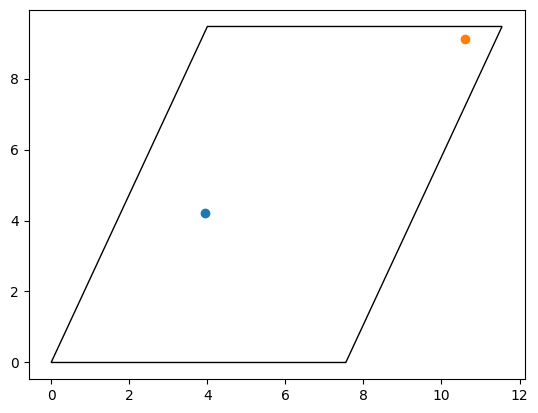

In [111]:
fig, ax = plt.subplots()
ax.scatter(pos_2d[0, 0], pos_2d[0, 1])
ax.scatter(pos_2d[1, 0], pos_2d[1, 1])

y = onp.array([[0, 0], a, a+b, b, [0, 0]])
p = Polygon(y, facecolor="none", edgecolor="black")

ax.add_patch(p)

In [98]:
cell_tilted_2d = cell_tilted[1:, 1:]

In [99]:
cell_tilted_2d

array([[7.54854037, 0.        ],
       [4.002805  , 9.4674266 ]])

In [108]:
# a, b = cell_tilted_2d
b, a = cell_tilted_2d

# Live experiment

In [ ]:
cell_tilted, pos_tilted

In [119]:
inv = jnp.linalg.pinv(cell_tilted)
pos_tilted_mapped = pos_tilted @ inv

atoms_mapped = Atoms(positions=pos_tilted_mapped[onp.array([0,3])], cell=[1,1,1], numbers=(0,10))

In [121]:
view(atoms_mapped)